In [173]:
# mounting gooogle drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
# import librearies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
# load the dataset
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Employee Salary Prediction/archive (2)/adult.csv')

In [176]:
# Data overview
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [177]:
#Dataset Strcuture
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [178]:
# Dataset description
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [179]:
# no. of rows and columns
df.shape

(32561, 15)

In [180]:
# check null values is present or not.
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


Before Preprocessing Visualization

Histogram

- Used histogram to count the approx income distribution.

- The target variable was imbalanced, with a significantly higher number of employees in the <=50K class compared to the >50K class. To reduce the impact of this imbalance, the class_weight='balanced' parameter was used during model training, allowing the model to assign higher importance to the minority class without using oversampling techniques such as SMOTE.

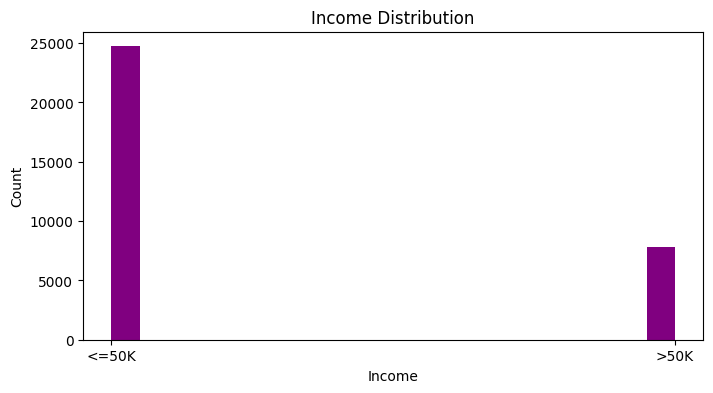

In [181]:
# income distribution
plt.figure(figsize=(8,4))
plt.hist(df['income'],bins=20,color='purple')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

Box Plot

- Used BoxPlot to check the outliers, is present or not in specific column.

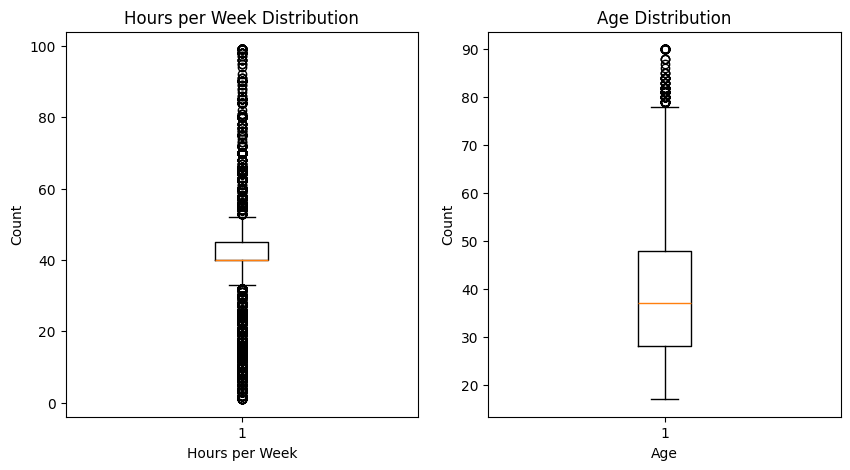

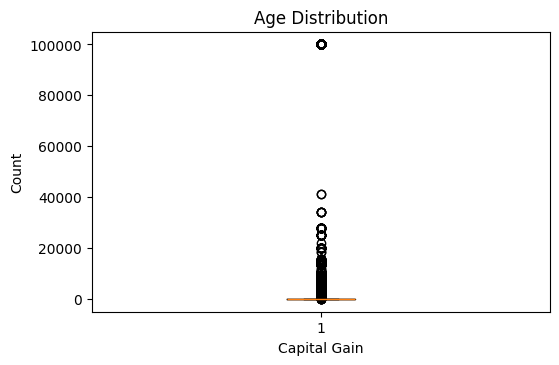

In [182]:
# used to check the outliers.
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.boxplot(df['hours.per.week'])
plt.title('Hours per Week Distribution')
plt.xlabel('Hours per Week')
plt.ylabel('Count')

plt.subplot(1,2,2)
plt.boxplot(df['age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.figure(figsize=(13,8))
plt.subplot(2,2,1)
plt.boxplot(df['capital.gain'])
plt.title('Age Distribution')
plt.xlabel('Capital Gain')
plt.ylabel('Count')

plt.show()

Pie Chart

- Used for show the proportion of income variable.

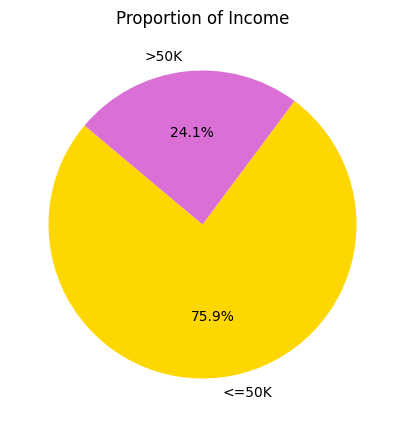

In [183]:
# used pie chart to check the income ratio.
counts = df['income'].value_counts()
plt.figure(figsize=(5, 5))
# 'autopct' automatically calculates and displays the percentages on the slices
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['gold', 'orchid'], startangle=140)
plt.title('Proportion of Income')
plt.show()

Scatter Plot

-Used scatter plot for finding relationship between variables

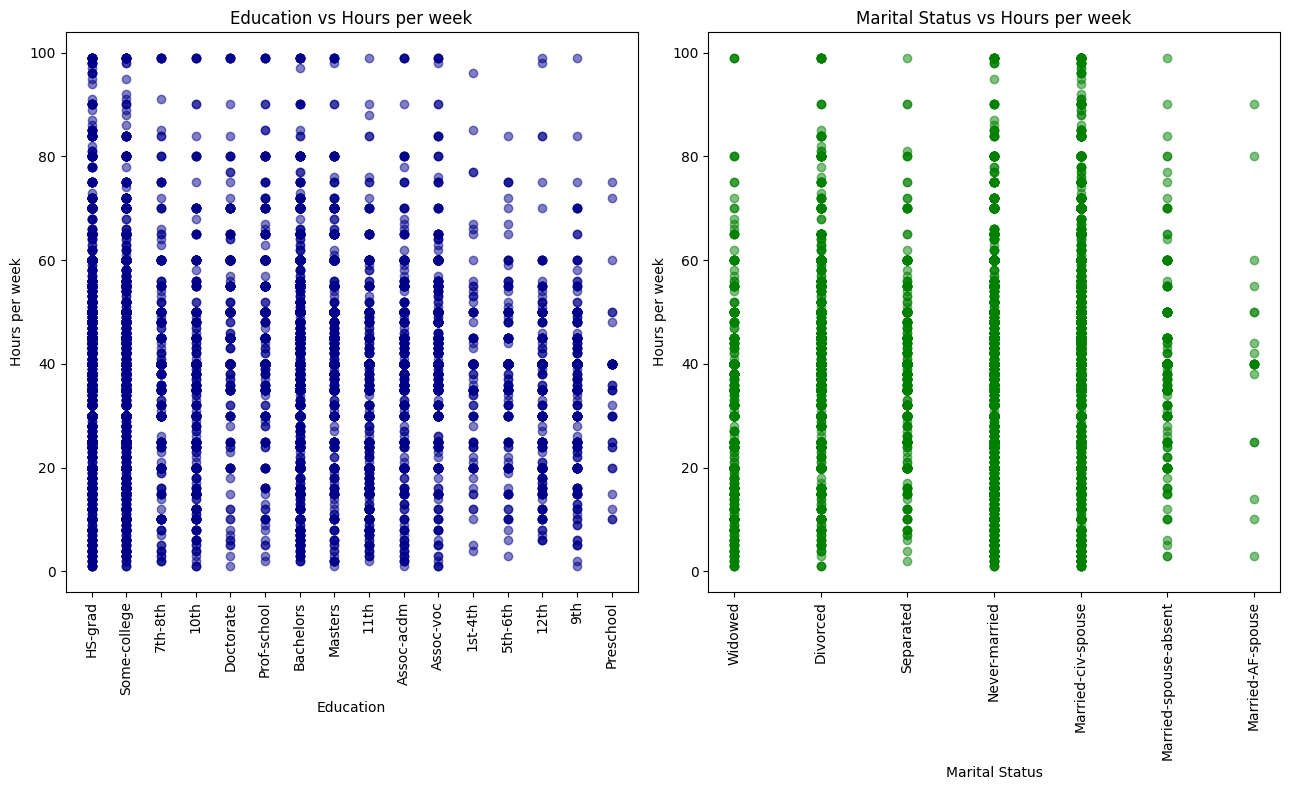

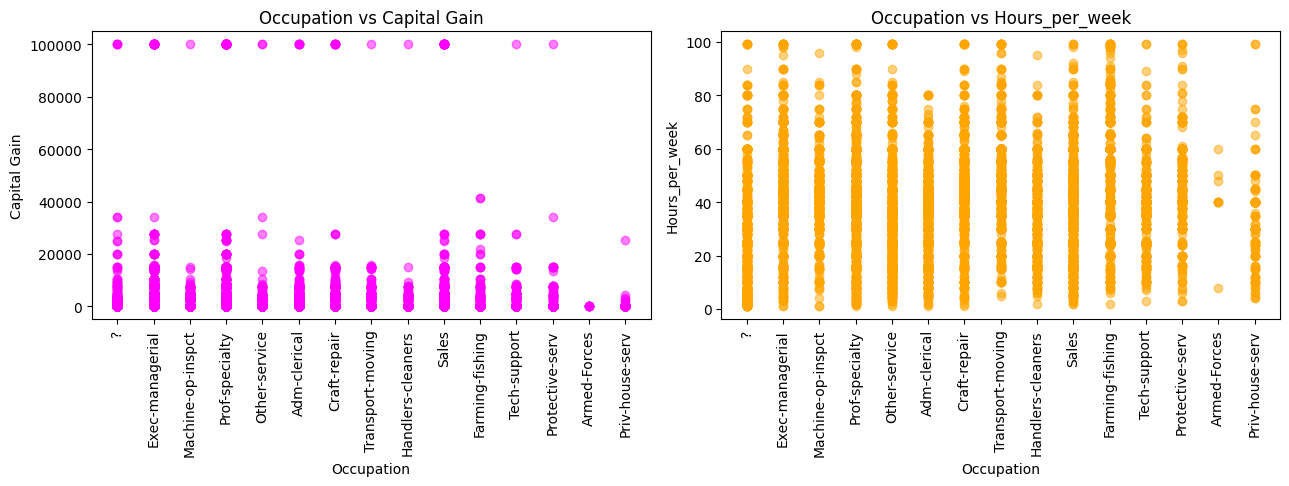

In [184]:
#Education vs Hours per week
plt.figure(figsize=(13,8))
plt.subplot(1,2,1)
plt.scatter(df['education'],df['hours.per.week'],alpha=0.5,color='darkblue')
plt.title('Education vs Hours per week')
plt.xlabel('Education')
plt.ylabel('Hours per week')
plt.xticks(rotation=90)

#Marital Status vs Hours per week
plt.subplot(1,2,2)
plt.scatter(df['marital.status'],df['hours.per.week'],alpha=0.5,color='green')
plt.title('Marital Status vs Hours per week')
plt.xlabel('Marital Status')
plt.ylabel('Hours per week')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#ccupation vs Capital Gain
plt.figure(figsize=(13,8))
plt.subplot(2,2,1)
plt.scatter(df['occupation'],df['capital.gain'],alpha=0.5,color='magenta')
plt.title('Occupation vs Capital Gain')
plt.xlabel('Occupation')
plt.ylabel('Capital Gain')
plt.xticks(rotation=90)
plt.tight_layout()

#Occupation vs Hours_per_week
plt.subplot(2,2,2)
plt.scatter(df['occupation'],df['hours.per.week'],alpha=0.5,color='orange')
plt.title('Occupation vs Hours_per_week')
plt.xlabel('Occupation')
plt.ylabel('Hours_per_week')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Correlation Heatmap

- A correlation heatmap is used to visualize the relationship between numerical features in the dataset. It helps identify highly correlated variables, detect multicollinearity, and support feature selection by highlighting redundant features.

<Axes: >

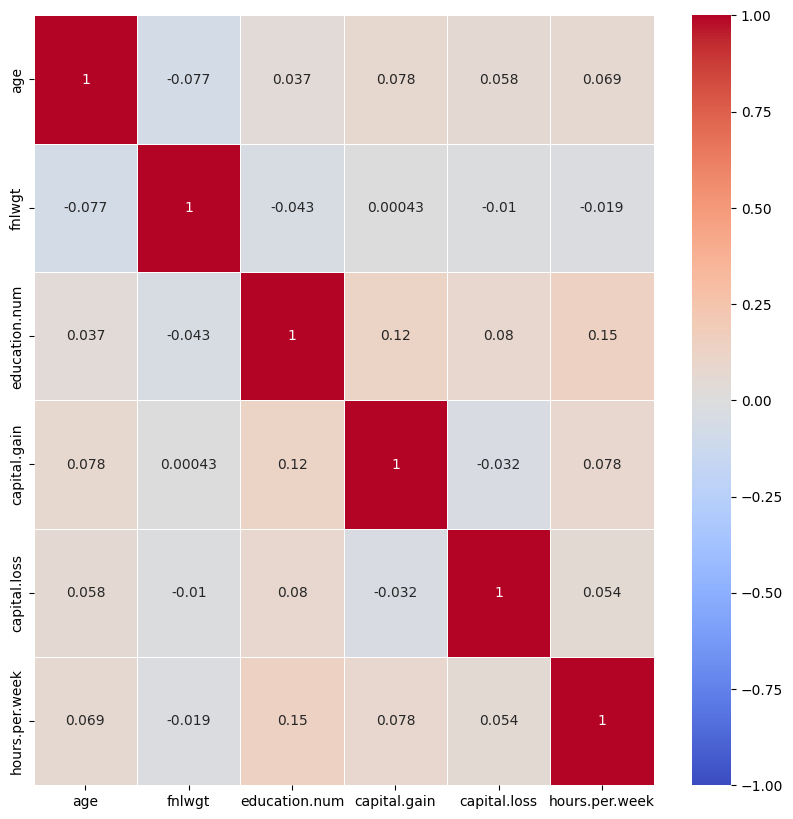

In [185]:
corr_matirx=df.corr(numeric_only=True)
plt.figure(figsize=(10,10))

sns.heatmap(
    corr_matirx,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
    )



## 1.Handling Missing values

- Handling missing values where it is present.

In [186]:
# null values present in form of '?'
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [187]:
# to know the percentage value of unique data in specific column. Workclass
df['workclass'].value_counts(normalize=True)*100

,proportion
workclass,
Private,69.703019
Self-emp-not-inc,7.803814
Local-gov,6.427935
?,5.638647
State-gov,3.986364
Self-emp-inc,3.427413
Federal-gov,2.948312
Without-pay,0.042996
Never-worked,0.021498


In [188]:
# replace the missing data to most frquent data.
df['workclass']=df['workclass'].replace('?','Private')

In [189]:
# missing values are present in form of '?'
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
?,1843
Transport-moving,1597


In [190]:
# check the percentage proportion of each occuaption.
df['occupation'].value_counts(normalize=True)*100

,proportion
occupation,
Prof-specialty,12.714597
Craft-repair,12.588680
Exec-managerial,12.487331
Adm-clerical,11.578268
Sales,11.209729
Other-service,10.119468
Machine-op-inspct,6.148460
?,5.660146
Transport-moving,4.904641


In [191]:
# replace missing values with most frequent data.
df['occupation']=df['occupation'].replace('?','Prof-specialty')

## 2.Remove unwanted columns.

- remove fnlwgt doesn't help to improving model training.
- remove education.num, beacuse it is duplicate of education.
- remove race beacuse it doesnt improve accuracy, precision,f1-score.
- remove sex because it doesnt improve accuracy, precision,f1-score.
- remove native.country beacuse it doesnt improve accuracy, precision,f1-score.

In [192]:
# remove captial.gain column because each rows contain 0.
df=df.drop(columns=['fnlwgt','education.num','capital.loss','sex','race','native.country'],axis=1)


## 3.Feature Selection

-Feature selection helps improve model performance by keeping only the most relevant features for prediction. It reduces unnecessary complexity, minimizes overfitting, decreases training time, and makes the model easier to interpret. Features were selected based on their relevance to salary prediction and their impact on model performance.

In [193]:
# find out the percentage of each data
df['capital.gain'].value_counts(normalize=True)*100

,proportion
capital.gain,
0,91.671017
15024,1.065692
7688,0.872209
7298,0.755505
99999,0.488314
...,...
2538,0.003071
2387,0.003071
1455,0.003071


In [194]:
# convert it from number to Yes/No.
df['capital.gain']=np.where(df['capital.gain']==0,'No','Yes')

Rename Columns

In [195]:
df=df.rename(columns={'education.num':'education',
                      'marital.status':'marital_status',
                      'hours.per.week':'hours_per_week',
                      'capital.gain':'capital_gain'})

In [196]:
df.head(15)

,age,workclass,education,marital_status,occupation,relationship,capital_gain,hours_per_week,income
0,90,Private,HS-grad,Widowed,Prof-specialty,Not-in-family,No,40,<=50K
1,82,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,No,18,<=50K
2,66,Private,Some-college,Widowed,Prof-specialty,Unmarried,No,40,<=50K
3,54,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,No,40,<=50K
4,41,Private,Some-college,Separated,Prof-specialty,Own-child,No,40,<=50K
5,34,Private,HS-grad,Divorced,Other-service,Unmarried,No,45,<=50K
6,38,Private,10th,Separated,Adm-clerical,Unmarried,No,40,<=50K
7,74,State-gov,Doctorate,Never-married,Prof-specialty,Other-relative,No,20,>50K
8,68,Federal-gov,HS-grad,Divorced,Prof-specialty,Not-in-family,No,40,<=50K
9,41,Private,Some-college,Never-married,Craft-repair,Unmarried,No,60,>50K


## 4.Reduce Categories

- Why Reduce Categories?

Some categorical features contained many unique values with very few observations. These categories were grouped into a common category (e.g., "Other") to reduce dimensionality after one-hot encoding, improve model generalization, and prevent the model from learning patterns from very rare categories.

In [197]:
df['workclass'].value_counts()

,count
workclass,
Private,24532
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


Reducing workclass categories

- if there is more categories, after encoding more number of catgeories created so merge it with the data who's similar.

In [198]:
# reduce the workclass categories
df['workclass']=df['workclass'].replace(['Self-emp-not-inc','Self-emp-inc'],('Private'))
df['workclass']=df['workclass'].replace(['Local-gov','State-gov','Federal-gov'],('Government'))
df['workclass']=df['workclass'].replace(['Without-pay','Never-worked'],('Other'))


Reducing marital_status

In [199]:
df['marital_status'].value_counts()

,count
marital_status,
Married-civ-spouse,14976
Never-married,10683
Divorced,4443
Separated,1025
Widowed,993
Married-spouse-absent,418
Married-AF-spouse,23


In [200]:
# reduce the marital_status categories
marital_status_map={
    'Married-civ-spouse':'Married',
    'Married-spouse-absent':'Married',
    'Married-AF-spouse':'Married',
    'Divorced':'Single',
    'Separated':'Single',
    'Widowed':'Single'
}
df['marital_status']=df['marital_status'].replace(marital_status_map)


Reducing the occupation category

In [201]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,5983
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Transport-moving,1597
Handlers-cleaners,1370


In [202]:
# reduce the occupation category
# find top 5 occupation.
occupation_map=df['occupation'].value_counts().nlargest(5).index
# replace anything NOT in the top 5 with other
df['occupation']=df['occupation'].apply(lambda x: x if x in occupation_map else 'Other')

Reducing Education category

In [203]:
# reduce Education category
df['education']=df['education'].replace(['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th'],('School'))
df['education']=df['education'].replace(['HS-grad','Some-college','Prof-school','Bachelors','Masters'],('Graduation'))
df['education']=df['education'].replace(['Assoc-voc','Assoc-acdm','Doctorate'],('PhD'))


In [204]:
df['education'].value_counts()

,count
education,
Graduation,25446
School,4253
PhD,2862


## 5. Train test Split data

In [205]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('income',axis=1),df['income'],test_size=0.2,random_state=42)

## 6. OneHotEncoder Encoding

we apply OneHotEncoder in Nominal Data.

- workclass
- marital_status
 - occupation

### Column Transformer

Why ColumnTransformer?

The dataset contains both numerical and categorical features, which require different preprocessing techniques. ColumnTransformer allows different transformations to be applied simultaneously—for example, One-Hot Encoding for categorical features and MinMax Scaling for numerical features—while keeping the preprocessing pipeline organized and reproducible.

In [206]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

ct=ColumnTransformer(transformers=[
    ('tf1',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),['workclass','marital_status','relationship','education','occupation','capital_gain']),
    ('tf2',MinMaxScaler(),[0,7])

],remainder='passthrough')

In [207]:
# convert the to array to pandas.
ct.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('tf1',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['workclass', 'marital_status', 'relationship',
                                  'education', 'occupation', 'capital_gain']),
                                ('tf2', MinMaxScaler(), [0, 7])])

In [208]:
X_train_transform=ct.fit_transform(X_train)
X_test_transform=ct.transform(X_test)

In [209]:
# to see the education column after transformation
edu_cols=[col for col in X_train_transform.columns if 'education' in col]
print(X_train_transform[edu_cols].head())



       tf1__education_PhD  tf1__education_School
5514                  0.0                    0.0
19777                 0.0                    0.0
10781                 0.0                    0.0
32240                 0.0                    0.0
9876                  0.0                    0.0


## 7.Label Encoder

- It converts the tagret variable into binary for 0 or 1.

In [210]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
transformed_y_train=le.fit_transform(y_train)
transformed_y_test=le.fit_transform(y_test)


In [211]:
transformed_y_train

array([0, 0, 0, ..., 1, 1, 0])

In [212]:
# scaling
from sklearn.feature_selection import SelectKBest,chi2
selector=SelectKBest(score_func=chi2,k=6)


## 8.Model Training

###Used RandomForestClassifier

Why Random Forest?

- Random Forest was selected because it is an ensemble learning algorithm that combines multiple decision trees to produce robust predictions. It handles both numerical and categorical features effectively, is less prone to overfitting than a single decision tree, and performs well on classification problems without requiring extensive feature scaling.

In [213]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rc=RandomForestClassifier(random_state=42,max_samples=0.75,class_weight='balanced')   # used class balanced give the qual important to both categories.
rc.fit(X_train_transform,y_train)
random_forest_y_pred=rc.predict(X_test_transform)
accuracy_score(y_test,random_forest_y_pred)

0.7924151696606786

###Pipeline

Why Pipeline?

- A Pipeline combines all preprocessing steps and the machine learning model into a single workflow. This ensures that the same transformations are consistently applied during both training and prediction, reduces the risk of data leakage, and simplifies model deployment.

Pipeline for RandomForestClassifier



In [214]:
from sklearn.pipeline import Pipeline
random_forest_pipe=Pipeline([
    ('ct',ct),
    ('selector',selector),
    ('rc',rc)
])

random_forest_pipe.fit(X_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tf1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['workclass',
                                                   'marital_status',
                                                   'relationship', 'education',
                                                   'occupation',
                                                   'capital_gain']),
                                                 ('tf2', MinMaxScaler(),
                                                  [0, 7])])),
                ('selector',
                 SelectKBest(k=6,
                             score_func=<function chi2 at 0x7fb2d618b1a0>)),
                ('rc',
                 RandomForestClassifier(class_weight='balanced',
                                        max_samples=0.75, random_state=42))])

### Feature Importance

In [215]:
# get the features name after preprocessing, beacuse original name are changed after the onehotencoder.
feature_names = random_forest_pipe.named_steps['ct'].get_feature_names_out()
selected_features=feature_names[selector.get_support()]
selected_features=[name.replace('tf1__',' ') for name in selected_features]

In [216]:
# get the importance of each column inside the pipeline.
importance=random_forest_pipe.named_steps['rc'].feature_importances_

In [217]:
importance_df = pd.DataFrame({
    'Feature':selected_features,
    'Importance':importance
})

importance_df=importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [218]:
print(importance_df)

                         Feature  Importance
0   marital_status_Never-married    0.359040
1     relationship_Not-in-family    0.159747
5               capital_gain_Yes    0.147568
2         relationship_Own-child    0.142190
3               education_School    0.117123
4     occupation_Exec-managerial    0.074331


In [219]:
print(importance)

[0.35904032 0.15974697 0.14219047 0.11712296 0.07433149 0.14756779]


Bar Plot of Feature Importance

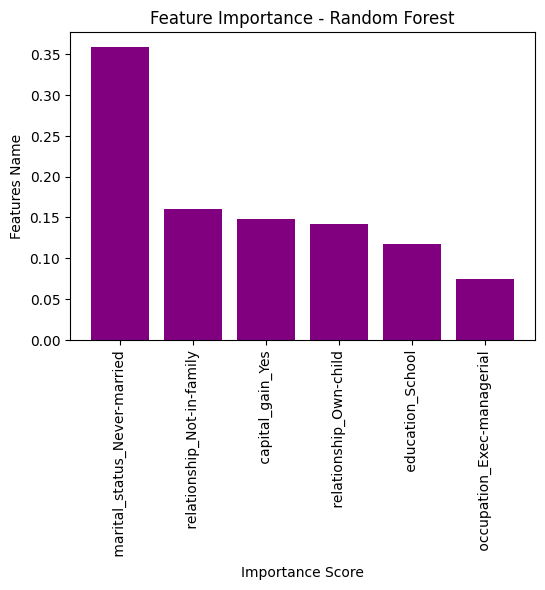

In [220]:
plt.figure(figsize=(6,4))
plt.bar(
    importance_df['Feature'],
    importance_df['Importance'],
    color='purple'
    )

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features Name')
plt.xticks(rotation=90)

plt.show()


### Logistic Regresiion

Why Logistic Regression?

- Logistic Regression was used as a baseline classification model. It is simple, computationally efficient, and provides a good benchmark for comparing the performance of more complex models such as Random Forest.

In [221]:

# without class balanced
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr=LogisticRegression(class_weight='balanced')
lr.fit(X_train_transform,y_train)
logistic_reg_y_pred=lr.predict(X_test_transform)
accuracy_score(y_test,logistic_reg_y_pred)

0.7742975587286964

Pipeline for Logistic Regression

In [222]:
logistic_reg_pipe=Pipeline([
    ('ct',ct),
    ('selector',selector),
    ('lr',lr)
])

logistic_reg_pipe.fit(X_train,y_train)

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tf1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['workclass',
                                                   'marital_status',
                                                   'relationship', 'education',
                                                   'occupation',
                                                   'capital_gain']),
                                                 ('tf2', MinMaxScaler(),
                                                  [0, 7])])),
                ('selector',
                 SelectKBest(k=6,
                             score_func=<function chi2 at 0x7fb2d618b1a0>)),
                ('lr', LogisticRegression(class_weight='balanced'))])

## 9.Hyperameter Tuning

Why Hyperparameter Tuning?

-Hyperparameter tuning was performed using RandomizedSearchCV to identify the optimal combination of model parameters. This process helps improve the model's predictive performance and generalization by systematically evaluating multiple parameter combinations using cross-validation.

####RandomizedSearchCV

- RandomizedSearchCV was used to find the optimal hyperparameters for the Random Forest model. It evaluates multiple random parameter combinations using cross-validation and selects the best-performing model, improving prediction performance while reducing computational cost.

In [223]:
n_estimators=[20,30,40,60]
max_features=[0.2,0.6,1.0]
max_depth=[2,8,None]
max_samples=[0.5,0.7,0.8]
bootstrap=[True,False]
min_samples_split=[2,5]
min_samples_leaf=[1,2]


In [224]:
para_grid={
    'n_estimators':n_estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'max_samples':max_samples,
    'bootstrap':bootstrap,
    'min_samples_split':min_samples_split,
    'min_samples_leaf':min_samples_leaf
}

In [225]:
from sklearn.model_selection import RandomizedSearchCV
rs=RandomizedSearchCV(
    estimator=rc,
    param_distributions=para_grid,
    cv=5,
    verbose=2,
    n_jobs=-1

)

In [226]:
rs.fit(X_train_transform,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    max_samples=0.75,
                                                    random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.7, 0.8],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 30, 40, 60]},
                   verbose=2)

In [227]:
# pipeline
randomized_pipe=Pipeline([
    ('ct',ct),
    ('selector',selector),
    ('rs',rs)
])
randomized_pipe.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

Pipeline(steps=[('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tf1',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['workclass',
                                                   'marital_status',
                                                   'relationship', 'education',
                                                   'occupation',
                                                   'capital_gain']),
                                                 ('tf2', MinMaxScaler(),
                                                  [0, 7])])),
                ('selector',
                 SelectKBest(k=6,
                             score_func=<function chi2 at 0x7fb2d618b1a0>)),
                ('rs',
                 RandomizedSearchCV(cv=5,
                                    estimator=RandomForestClassifier(class_weight='balanced',
                                                                     max_samples=0.75,
                                                                     random_state=42),
                                    n_jobs=-1,
                                    param_distributions={'bootstrap': [True,
                                                                       False],
                                                         'max_depth': [2, 8,
                                                                       None],
                                                         'max_features': [0.2,
                                                                          0.6,
                                                                          1.0],
                                                         'max_samples': [0.5,
                                                                         0.7,
                                                                         0.8],
                                                         'min_samples_leaf': [1,
                                                                              2],
                                                         'min_samples_split': [2,
                                                                               5],
                                                         'n_estimators': [20,
                                                                          30,
                                                                          40,
                                                                          60]},
                                    verbose=2))])

In [228]:
# best score.
rs.best_score_

np.float64(0.6861178625949698)

### Confusion Matrix

Why Confusion Matrix?

- A Confusion Matrix is used to evaluate the performance of a classification model by comparing the actual and predicted class labels. It provides the number of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN), helping identify the types of prediction errors made by the model.

Confusion Matrix of Random Forest Classifier

In [229]:
from sklearn.metrics import confusion_matrix
random_forest_y_pred=random_forest_pipe.predict(X_test)
print("Confusion Matrix of Random Forest Classifier")
print(confusion_matrix(y_test,random_forest_y_pred))

Confusion Matrix of Random Forest Classifier
[[3084 1892]
 [ 169 1368]]


Confusion Matrix of Logistic Regression

In [230]:
logistic_reg_y_pred=logistic_reg_pipe.predict(X_test)

print("Confusion Matrix")
print(confusion_matrix(y_test,logistic_reg_y_pred))

Confusion Matrix
[[3043 1933]
 [ 172 1365]]


## 10.Classification Report

Why Classification Report?

- The Classification Report provides a detailed evaluation of the model using Precision, Recall, F1-Score, and Support for each class. These metrics help measure not only the overall accuracy but also how effectively the model predicts each class, making it especially useful for evaluating imbalanced datasets.

Random Forest Classifier Report

In [231]:
from sklearn.metrics import precision_score,classification_report,confusion_matrix
print(classification_report(y_test,random_forest_y_pred))

              precision    recall  f1-score   support

       <=50K       0.95      0.62      0.75      4976
        >50K       0.42      0.89      0.57      1537

    accuracy                           0.68      6513
   macro avg       0.68      0.75      0.66      6513
weighted avg       0.82      0.68      0.71      6513



Logistic Regression Report

In [232]:
from sklearn.metrics import precision_score,classification_report,confusion_matrix
print(classification_report(y_test,logistic_reg_y_pred))

              precision    recall  f1-score   support

       <=50K       0.95      0.61      0.74      4976
        >50K       0.41      0.89      0.56      1537

    accuracy                           0.68      6513
   macro avg       0.68      0.75      0.65      6513
weighted avg       0.82      0.68      0.70      6513



## 11.Save the Model

In [233]:
# saving model
import pickle
pickle.dump(random_forest_pipe,open('model.pkl','wb'))

### Testing on data

In [234]:
# load the model
clf=pickle.load(open('/content/model.pkl','rb'))

In [235]:
# take user input
col_names=['age','workclass','education','marital_status','occupation','relationship','capital_gain','hours_per_week']
user=np.array([[52,'Private','Graduation','Single','Other','Not-in-family','Yes',50]],dtype=object)
user_input=pd.DataFrame(user,columns=col_names)

In [236]:
# model predcition on data
clf.predict(user_input)

array(['>50K'], dtype=object)

## 12. Future Improvements

- Handle class imbalance using SMOTE
- Try XGBoost / LightGBM for better performance on imbalanced data
- Try GridSearchCV with narrower param range after RandomizedSearch
- Add batch prediction (CSV upload) in Streamlit app
- Add ROC-AUC curve for better model comparison

##13. Conclusion

An Employee Salary Prediction model was successfully developed using machine learning techniques. After performing data preprocessing, feature engineering, hyperparameter tuning, and model evaluation, the Random Forest Classifier produced the best performance. The final model was deployed using Streamlit, enabling users to predict employee salary categories through an interactive web application.